# OpenKind — Phase 4E QASPER Error & Evidence Audit

**Purpose:** determine whether the remaining QASPER applicability failures are primarily label/evidence ambiguity or a representation failure before spending more GPU time. Phase 4E-A performs no training and never opens final.

**Workbench:** `4e.0.0`  
**Immutable corpus run:** `20260921T013558Z`  
**Diagnostic parent:** Phase 4D epoch 0, which exactly retains the Phase 4B.2.1 stratified checkpoint  
**Default mode:** `prepare_audit`  
**Runtime:** CPU is sufficient

## Why Phase 4E follows Phase 4A–4D

| Completed test | Decisive number | Lesson carried into 4E |
|---|---:|---|
| Scalar none weight | Cap 12 realizes only `8.5602`; QASPER gate recall `0.1556`; ContractNLI false-none `0.3966` | The scalar sweep is saturated and closed. |
| Stratified applicability | QASPER operating recall `0.2564` on policy development and `0.3111` on the gate; gate policy cost `0.11675` | Best surviving parent, but not a promotion candidate. |
| Pairwise applicability | Development QASPER recall `0.3451`; gate false-none `0.2110`; gate policy cost `0.10221` | A development pass did not transfer. |
| Head-only continuation | Two extra QASPER true positives; NLL/Brier regress `2.77%/2.10%` | Do not retune the same pooled head. |
| Evidence residual | One extra QASPER true positive; NLL/Brier regress `6.08%/6.60%` | Shallow handcrafted diagnostics do not repair the boundary. |

For the retained parent, QASPER policy-development ROC AUC/AP is `0.5903/0.1663` at prevalence `39/320 = 0.1219`; the calibration-gate values are `0.6173/0.1841` at prevalence `90/692 = 0.1301`. The next useful evidence is therefore a blinded review of actual false negatives and false positives—not another nearby weight, margin, head, or residual sweep.

Phase 4E-A builds a 150-item audit pack:

- all 70 policy-development errors: 29 false negatives and 41 false positives;
- a deterministic, state-diverse calibration-gate sample: 30 false negatives and 30 false positives;
- 10 true-positive and 10 true-negative policy-development controls.

The reviewer file hides locked targets, model predictions, none probabilities, thresholds, and error classes. Those fields remain in a separately hash-locked key. Phase 4E-B representation learning is **not automatically authorized** by this notebook; completed review and adjudication are required first.

## Recommended run sequence

1. Run top to bottom with `MODE = "prepare_audit"`. A CPU Colab runtime is enough.
2. Review `AUDIT_GUIDE.md`, fill every reviewer field in `AUDIT_REVIEW_BLINDED.csv`, and save the completed copy as `AUDIT_REVIEW_COMPLETED.csv` in the same run directory.
3. Change only `MODE` to `"analyze_review"` and rerun the notebook.
4. Preserve the generated contract, manifest, blinded pack, locked key, analysis, and result lock unchanged.

Do not change the parent, thresholds, seed, sample counts, or review taxonomy inside this run label. A changed audit design requires a new `RUN_LABEL`. Do not open final and do not start seeds 42/123 from this notebook.

## 1. Runtime and dependency contract

In [46]:
import sys, subprocess, importlib.metadata as im, json, platform

def installed(name):
    try:
        return im.version(name)
    except im.PackageNotFoundError:
        return None

required = {
    "numpy": "numpy>=2,<3",
    "pandas": "pandas>=2,<3",
    "pyarrow": "pyarrow>=18,<30",
    "scikit-learn": "scikit-learn>=1.6,<2",
    "matplotlib": "matplotlib>=3.9,<4",
}
missing = [spec for name, spec in required.items() if installed(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ENVIRONMENT = {
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {name: installed(name) for name in required},
}
print(json.dumps(ENVIRONMENT, indent=2, allow_nan=False))

{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "packages": {
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "pyarrow": "23.0.1",
    "scikit-learn": "1.6.1",
    "matplotlib": "3.10.0"
  }
}


## 2. Mount Google Drive

In [47]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Configure the immutable audit

In [48]:
import hashlib
import math
import os
import re
from datetime import datetime, timezone
from pathlib import Path

WORKBENCH_VERSION = "4e.0.0"
BASE_RUN_ID = "20260921T013558Z"
SEED = 17
RUN_LABEL = "qasper_error_audit_s17"

# Change only this field between the two prescribed passes.
MODE = "analyze_review"  # prepare_audit | analyze_review

if MODE not in {"prepare_audit", "analyze_review"}:
    raise ValueError("MODE must be prepare_audit or analyze_review.")
if not re.fullmatch(r"[a-z0-9][a-z0-9._-]{0,79}", RUN_LABEL):
    raise ValueError("RUN_LABEL must be a short path-safe identifier.")

CFG = {
    "schema": "openkind-phase4e-qasper-audit-config/v1",
    "workbench_version": WORKBENCH_VERSION,
    "base_run_id": BASE_RUN_ID,
    "seed": SEED,
    "run_label": RUN_LABEL,
    "mode": MODE,
    "source": "qasper",
    "policy_development": {
        "include_all_false_negatives": True,
        "include_all_false_positives": True,
        "true_positive_controls": 10,
        "true_negative_controls": 10,
    },
    "calibration_gate": {
        "sample_false_negatives": 30,
        "sample_false_positives": 30,
        "sampling": "deterministic_state_round_robin_sha256",
    },
    "review_target_kinds": ["answerable", "semantic_none", "ambiguous"],
    "final_split_available": False,
    "final_opened": False,
}

COLAB_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")
BASE_RUN = COLAB_ROOT / "OpenKind_Phase4A_StateQuery_results" / BASE_RUN_ID
PHASE4D_RUN = (
    COLAB_ROOT
    / "OpenKind_Phase4D_EvidenceAware_Applicability_results"
    / BASE_RUN_ID
    / "b2_evidence_residual_s17"
)
OUTPUT_ROOT = (
    COLAB_ROOT
    / "OpenKind_Phase4E_QASPER_Audit_results"
    / BASE_RUN_ID
)
AUDIT_DIR = OUTPUT_ROOT / RUN_LABEL
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED = {
    "phase4d_experiment_sha256": "70ac547c7a257d978cbc241f049fb2dbbc912b0d5801ca28080820d1e183d4c5",
    "phase4d_selected_checkpoint_sha256": "314d3a45009a51159bb74bebed9806af76d1df103a14eca9a38160d0dab0d972",
    "phase4d_nonfinal_report_sha256": "9cc328dd3deeafb175aabaf18ba2daaf9914863b95879368a61416582c96680b",
    "policy_development_predictions_sha256": "401aaf4ee9139fa178155c0fbb1a4efa232d8c43ac69604a79b931d09792d90c",
    "calibration_gate_predictions_sha256": "fa87dde72ea7e268d6a5f80802d1e70b27818346cf612c178ac7cc0402ab3a3a",
    "qasper_threshold": 0.21089398860931396,
    "policy_development_counts": {"fn": 29, "fp": 41, "tp": 10},
    "calibration_gate_counts": {"fn": 62, "fp": 93, "tp": 28},
}

print(json.dumps(CFG, indent=2, allow_nan=False))
print("Immutable corpus input:", BASE_RUN)
print("Immutable Phase 4D input:", PHASE4D_RUN)
print("Phase 4E output:", AUDIT_DIR)

{
  "schema": "openkind-phase4e-qasper-audit-config/v1",
  "workbench_version": "4e.0.0",
  "base_run_id": "20260921T013558Z",
  "seed": 17,
  "run_label": "qasper_error_audit_s17",
  "mode": "analyze_review",
  "source": "qasper",
  "policy_development": {
    "include_all_false_negatives": true,
    "include_all_false_positives": true,
    "true_positive_controls": 10,
    "true_negative_controls": 10
  },
  "calibration_gate": {
    "sample_false_negatives": 30,
    "sample_false_positives": 30,
    "sampling": "deterministic_state_round_robin_sha256"
  },
  "review_target_kinds": [
    "answerable",
    "semantic_none",
    "ambiguous"
  ],
  "final_split_available": false,
  "final_opened": false
}
Immutable corpus input: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4A_StateQuery_results/20260921T013558Z
Immutable Phase 4D input: /content/drive/MyDrive/Colab Notebooks/OpenKind_Phase4D_EvidenceAware_Applicability_results/20260921T013558Z/b2_evidence_residual_s17
Phase 4E ou

## 4. Strict JSON and hashing helpers

In [49]:
import numpy as np
import pandas as pd

def json_safe(value):
    if isinstance(value, np.ndarray):
        return [json_safe(item) for item in value.tolist()]
    if isinstance(value, np.generic):
        value = value.item()
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    if value is pd.NA:
        return None
    if isinstance(value, float) and not math.isfinite(value):
        return None
    return value

def canonical_bytes(obj):
    return json.dumps(
        json_safe(obj), sort_keys=True, separators=(",", ":"),
        ensure_ascii=False, allow_nan=False,
    ).encode("utf-8")

def sha256_obj(obj):
    return hashlib.sha256(canonical_bytes(obj)).hexdigest()

def sha256_file(path, chunk=4 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(chunk):
            h.update(block)
    return h.hexdigest()

def reject_json_constant(token):
    raise ValueError(f"Non-standard JSON numeric constant: {token}")

def read_json(path):
    return json.loads(Path(path).read_text(), parse_constant=reject_json_constant)

def atomic_json(obj, destination):
    destination = Path(destination)
    tmp = destination.with_name(destination.name + ".partial")
    tmp.write_text(json.dumps(
        json_safe(obj), indent=2, ensure_ascii=False, allow_nan=False,
    ))
    os.replace(tmp, destination)

def atomic_text(text, destination):
    destination = Path(destination)
    tmp = destination.with_name(destination.name + ".partial")
    tmp.write_text(text)
    os.replace(tmp, destination)

probe = json.dumps(json_safe({"nan": np.nan, "inf": np.inf}), allow_nan=False)
assert json.loads(probe) == {"nan": None, "inf": None}
try:
    json.loads('{"bad": NaN}', parse_constant=reject_json_constant)
except ValueError:
    pass
else:
    raise AssertionError("Strict JSON reader accepted NaN.")
print("Strict JSON contract passed: unavailable/non-finite values serialize as null.")

Strict JSON contract passed: unavailable/non-finite values serialize as null.


## 5. Verify the frozen corpus, Phase 4D result, and closed final boundary

In [50]:
required_parent = [
    "EXPERIMENT_CONTRACT.json",
    "TRAINING_REPORT.json",
    "NONFINAL_EVALUATION.json",
    "NONFINAL_RESULT_LOCK.json",
    "policy_development_predictions.parquet",
    "calibration_gate_predictions.parquet",
]
missing = [name for name in required_parent if not (PHASE4D_RUN / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete Phase 4D run: {missing}")
if (PHASE4D_RUN / "FINAL_EVALUATION.json").exists():
    raise RuntimeError("Phase 4D final output exists; audit contract requires final closed.")

PARENT_CONTRACT = read_json(PHASE4D_RUN / "EXPERIMENT_CONTRACT.json")
PARENT_TRAINING = read_json(PHASE4D_RUN / "TRAINING_REPORT.json")
PARENT_REPORT = read_json(PHASE4D_RUN / "NONFINAL_EVALUATION.json")
PARENT_LOCK = read_json(PHASE4D_RUN / "NONFINAL_RESULT_LOCK.json")

if PARENT_CONTRACT["experiment_sha256"] != EXPECTED["phase4d_experiment_sha256"]:
    raise RuntimeError("Phase 4D experiment identity changed.")
for record in (PARENT_TRAINING, PARENT_REPORT, PARENT_LOCK):
    if record.get("experiment_sha256") != EXPECTED["phase4d_experiment_sha256"]:
        raise RuntimeError("Phase 4D artifact/contract mismatch.")
    if record.get("final_opened") is not False:
        raise RuntimeError("A Phase 4D artifact does not attest that final stayed closed.")
if PARENT_LOCK["status"] != "nonfinal_failed_final_unavailable":
    raise RuntimeError("Unexpected Phase 4D terminal status.")
if PARENT_LOCK["overall_nonfinal_pass"] is not False:
    raise RuntimeError("Phase 4D lock unexpectedly reports a pass.")
if PARENT_LOCK["selected_checkpoint_sha256"] != EXPECTED["phase4d_selected_checkpoint_sha256"]:
    raise RuntimeError("Phase 4D selected checkpoint identity changed.")
checkpoint = PHASE4D_RUN / PARENT_LOCK["selected_checkpoint"]
if not checkpoint.is_file() or sha256_file(checkpoint) != EXPECTED["phase4d_selected_checkpoint_sha256"]:
    raise RuntimeError("Phase 4D selected checkpoint file changed.")
if sha256_file(PHASE4D_RUN / "NONFINAL_EVALUATION.json") != EXPECTED["phase4d_nonfinal_report_sha256"]:
    raise RuntimeError("Phase 4D non-final report file changed.")

prediction_paths = {
    "policy_development": PHASE4D_RUN / "policy_development_predictions.parquet",
    "calibration_gate": PHASE4D_RUN / "calibration_gate_predictions.parquet",
}
for split, path in prediction_paths.items():
    expected_hash = EXPECTED[f"{split}_predictions_sha256"]
    if sha256_file(path) != expected_hash:
        raise RuntimeError(f"Changed Phase 4D prediction table: {split}")
    if PARENT_REPORT["prediction_files_sha256"][split] != expected_hash:
        raise RuntimeError(f"Phase 4D report hash mismatch: {split}")

threshold_record = PARENT_REPORT[
    "applicability_thresholds_selected_on_policy_development"
]["qasper"]
QASPER_THRESHOLD = float(threshold_record["threshold"])
if not math.isclose(QASPER_THRESHOLD, EXPECTED["qasper_threshold"], rel_tol=0, abs_tol=1e-15):
    raise RuntimeError("Frozen QASPER operating threshold changed.")

CORPUS_ROOT = BASE_RUN / "openkind-mq-v1"
CORPUS_MANIFEST = read_json(CORPUS_ROOT / "manifest.json")
CORPUS_LOCK = read_json(CORPUS_ROOT / "corpus_lock.json")
if CORPUS_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Corpus run ID changed.")
if sha256_obj(CORPUS_MANIFEST) != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Corpus manifest no longer matches its lock.")
if CORPUS_MANIFEST.get("final_labels_or_predictions_opened") is not False:
    raise RuntimeError("Corpus manifest does not attest that final stayed closed.")

frames = {}
for name, expected_hash in CORPUS_LOCK["tables"].items():
    path = CORPUS_ROOT / f"{name}.parquet"
    if sha256_file(path) != expected_hash:
        raise RuntimeError(f"Changed corpus table: {name}")
    frames[name] = pd.read_parquet(path)
    if len(frames[name]) != CORPUS_MANIFEST["counts"][name]:
        raise RuntimeError(f"Changed corpus row count: {name}")

final_state_ids = set(frames["states"].loc[
    frames["states"]["split"] == "final", "state_id"
])
if not final_state_ids:
    raise RuntimeError("Expected a reserved final-state set.")

INPUT_LOCK = {
    "phase4d_experiment_sha256": PARENT_CONTRACT["experiment_sha256"],
    "phase4d_checkpoint_sha256": PARENT_LOCK["selected_checkpoint_sha256"],
    "phase4d_nonfinal_report_sha256": sha256_file(PHASE4D_RUN / "NONFINAL_EVALUATION.json"),
    "prediction_files_sha256": {
        split: sha256_file(path) for split, path in prediction_paths.items()
    },
    "corpus_manifest_sha256": CORPUS_LOCK["manifest_sha256"],
    "corpus_tables_sha256": CORPUS_LOCK["tables"],
    "qasper_threshold": QASPER_THRESHOLD,
    "final_opened": False,
}
print(json.dumps(INPUT_LOCK, indent=2, allow_nan=False))

{
  "phase4d_experiment_sha256": "70ac547c7a257d978cbc241f049fb2dbbc912b0d5801ca28080820d1e183d4c5",
  "phase4d_checkpoint_sha256": "314d3a45009a51159bb74bebed9806af76d1df103a14eca9a38160d0dab0d972",
  "phase4d_nonfinal_report_sha256": "9cc328dd3deeafb175aabaf18ba2daaf9914863b95879368a61416582c96680b",
  "prediction_files_sha256": {
    "policy_development": "401aaf4ee9139fa178155c0fbb1a4efa232d8c43ac69604a79b931d09792d90c",
    "calibration_gate": "fa87dde72ea7e268d6a5f80802d1e70b27818346cf612c178ac7cc0402ab3a3a"
  },
  "corpus_manifest_sha256": "1aad04ca7d37ea8be640a51878857c6d2c501d635e913eca12234cb548f8399d",
  "corpus_tables_sha256": {
    "states": "7e6333202ad934e66148724a565b27176fcaad4133a566d2c8f8b57044ef3120",
    "questions": "549b446f609a9407eceb5df7ef4c0f14779bc73d72396ae749424626d8777434",
    "options": "cbd40c9162909c6c637296e9c8f408e0ba1bece0aca1786cef98f73d242f6cf2",
    "evidence": "566e0e69e8f57ed0ce626021647a3b770a89ae5a3eb318e1d4f8bea284f2c6be",
    "criteria": "

## 6. Reconstruct frozen-threshold QASPER outcomes

In [51]:
def parse_list(value):
    if isinstance(value, str):
        return json.loads(value)
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple)):
        return list(value)
    raise TypeError(f"Expected a serialized list, got {type(value).__name__}")

def add_operating_fields(frame, split):
    out = frame.loc[frame["source"].str.lower() == "qasper"].copy()
    out["partition"] = split

    def none_probability(row):
        option_ids = parse_list(row["option_ids"])
        probabilities = [float(x) for x in parse_list(row["probabilities"])]
        if len(option_ids) != len(probabilities) or "__none__" not in option_ids:
            raise RuntimeError(f"Invalid option/probability row: {row['question_id']}")
        if not math.isclose(sum(probabilities), 1.0, rel_tol=0, abs_tol=2e-5):
            raise RuntimeError(f"Probability sum error: {row['question_id']}")
        return probabilities[option_ids.index("__none__")]

    out["none_probability"] = out.apply(none_probability, axis=1)
    out["locked_semantic_none"] = out["target_label"].eq("__none__")
    out["operating_predicted_none"] = out["none_probability"].ge(QASPER_THRESHOLD)
    conditions = [
        out["locked_semantic_none"] & out["operating_predicted_none"],
        out["locked_semantic_none"] & ~out["operating_predicted_none"],
        ~out["locked_semantic_none"] & out["operating_predicted_none"],
    ]
    out["operating_outcome"] = np.select(conditions, ["tp", "fn", "fp"], default="tn")
    if out["question_id"].duplicated().any():
        raise RuntimeError(f"Duplicate QASPER question IDs in {split} predictions.")
    return out

prediction_frames = {
    split: add_operating_fields(pd.read_parquet(path), split)
    for split, path in prediction_paths.items()
}
policy = prediction_frames["policy_development"]
gate = prediction_frames["calibration_gate"]

def outcome_counts(frame):
    counts = frame["operating_outcome"].value_counts().to_dict()
    return {key: int(counts.get(key, 0)) for key in ("tp", "fn", "fp", "tn")}

COUNTS = {split: outcome_counts(frame) for split, frame in prediction_frames.items()}
for split in ("policy_development", "calibration_gate"):
    for key, expected_count in EXPECTED[f"{split}_counts"].items():
        if COUNTS[split][key] != expected_count:
            raise RuntimeError(
                f"Frozen {split} {key} count changed: "
                f"{COUNTS[split][key]} != {expected_count}"
            )
assert len(policy) == 320 and len(gate) == 692
assert COUNTS["policy_development"]["fn"] + COUNTS["policy_development"]["fp"] == 70

count_table = pd.DataFrame(COUNTS).T.reset_index(names="partition")
display(count_table)
print("Frozen QASPER threshold:", QASPER_THRESHOLD)

,partition,tp,fn,fp,tn
0,policy_development,10,29,41,240
1,calibration_gate,28,62,93,509


Frozen QASPER threshold: 0.21089398860931396


## 7. Inspect the score overlap before review

,experiment,qasper_recall,gate_policy_cost
0,cap-12 scalar,0.1556,0.10384
1,stratified parent,0.3111,0.11675
2,pairwise,0.3333,0.10221


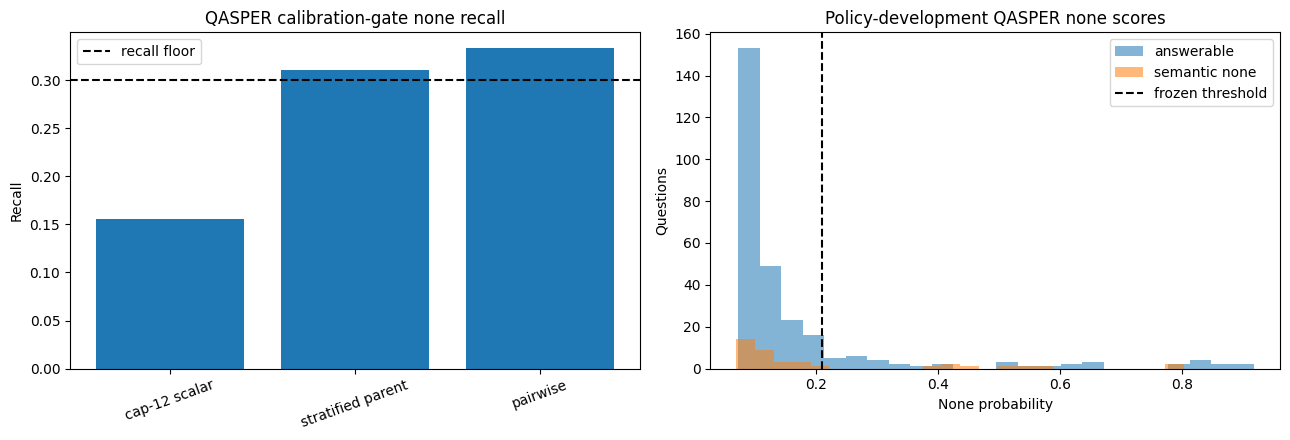

In [52]:
import matplotlib.pyplot as plt

phase_summary = pd.DataFrame([
    {"experiment": "cap-12 scalar", "qasper_recall": 0.1556, "gate_policy_cost": 0.10384},
    {"experiment": "stratified parent", "qasper_recall": 0.3111, "gate_policy_cost": 0.11675},
    {"experiment": "pairwise", "qasper_recall": 0.3333, "gate_policy_cost": 0.10221},
])
display(phase_summary)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(phase_summary["experiment"], phase_summary["qasper_recall"], color="tab:blue")
axes[0].axhline(0.30, color="black", linestyle="--", label="recall floor")
axes[0].set_title("QASPER calibration-gate none recall")
axes[0].set_ylabel("Recall")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

for target, group in policy.groupby("locked_semantic_none"):
    axes[1].hist(
        group["none_probability"], bins=24, alpha=0.55,
        label="semantic none" if target else "answerable",
    )
axes[1].axvline(QASPER_THRESHOLD, color="black", linestyle="--", label="frozen threshold")
axes[1].set_title("Policy-development QASPER none scores")
axes[1].set_xlabel("None probability")
axes[1].set_ylabel("Questions")
axes[1].legend()
plt.tight_layout()
plt.show()

## 8. Build the deterministic blinded review population

In [53]:
def stable_digest(*parts):
    payload = "|".join(str(part) for part in parts).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()

def state_round_robin_sample(frame, n, salt):
    if n > len(frame):
        raise ValueError(f"Requested {n} rows from only {len(frame)} candidates.")
    work = frame.copy()
    work["_state_order"] = work["state_id"].map(
        lambda value: stable_digest(SEED, salt, "state", value)
    )
    work["_item_order"] = work.apply(
        lambda row: stable_digest(SEED, salt, "item", row["state_id"], row["question_id"]),
        axis=1,
    )
    grouped = {
        state_id: list(group.sort_values("_item_order").index)
        for state_id, group in work.groupby("state_id", sort=False)
    }
    state_order = sorted(grouped, key=lambda state_id: stable_digest(SEED, salt, state_id))
    selected = []
    while len(selected) < n:
        added = False
        for state_id in state_order:
            if grouped[state_id] and len(selected) < n:
                selected.append(grouped[state_id].pop(0))
                added = True
        if not added:
            break
    if len(selected) != n:
        raise RuntimeError("Deterministic state-round-robin sampling underfilled.")
    return work.loc[selected].drop(columns=["_state_order", "_item_order"])

selected_parts = []

policy_errors = policy.loc[policy["operating_outcome"].isin(["fn", "fp"])].copy()
policy_errors["selection_role"] = "policy_all_error"
selected_parts.append(policy_errors)

for outcome, n in (("tp", 10), ("tn", 10)):
    sample = state_round_robin_sample(
        policy.loc[policy["operating_outcome"] == outcome], n,
        f"policy_control_{outcome}",
    )
    sample["selection_role"] = "policy_blinded_control"
    selected_parts.append(sample)

for outcome, n in (("fn", 30), ("fp", 30)):
    sample = state_round_robin_sample(
        gate.loc[gate["operating_outcome"] == outcome], n,
        f"gate_error_{outcome}",
    )
    sample["selection_role"] = "gate_state_diverse_error_sample"
    selected_parts.append(sample)

AUDIT_KEY_FRAME = pd.concat(selected_parts, ignore_index=True)
if len(AUDIT_KEY_FRAME) != 150:
    raise AssertionError(f"Expected 150 audit items, got {len(AUDIT_KEY_FRAME)}")
if AUDIT_KEY_FRAME["question_id"].duplicated().any():
    raise RuntimeError("Audit population contains duplicate question IDs.")
if set(AUDIT_KEY_FRAME["state_id"]) & final_state_ids:
    raise RuntimeError("Audit population includes a final state.")

AUDIT_KEY_FRAME["review_id"] = AUDIT_KEY_FRAME.apply(
    lambda row: "ok4e_" + stable_digest(
        "openkind-phase4e", row["partition"], row["question_id"]
    )[:16], axis=1,
)
AUDIT_KEY_FRAME["blinded_order"] = AUDIT_KEY_FRAME["review_id"].map(
    lambda value: stable_digest(SEED, "blinded_order", value)
)
AUDIT_KEY_FRAME = AUDIT_KEY_FRAME.sort_values("blinded_order").reset_index(drop=True)

selection_summary = (
    AUDIT_KEY_FRAME.groupby(["partition", "selection_role", "operating_outcome"])
    .size().rename("n").reset_index()
)
display(selection_summary)

,partition,selection_role,operating_outcome,n
0,calibration_gate,gate_state_diverse_error_sample,fn,30
1,calibration_gate,gate_state_diverse_error_sample,fp,30
2,policy_development,policy_all_error,fn,29
3,policy_development,policy_all_error,fp,41
4,policy_development,policy_blinded_control,tn,10
5,policy_development,policy_blinded_control,tp,10


## 9. Join only reviewer-visible text; retain model fields in the locked key

In [54]:
states = frames["states"].set_index("state_id", drop=False)
questions = frames["questions"].set_index("question_id", drop=False)

option_groups = {}
for question_id, group in frames["options"].groupby("question_id"):
    if "position" in group.columns:
        group = group.sort_values("position")
    option_groups[question_id] = [
        {"option_id": str(row["option_id"]), "description": str(row.get("description", ""))}
        for _, row in group.iterrows()
    ]

evidence_groups = {}
if "evidence" in frames:
    for question_id, group in frames["evidence"].groupby("question_id"):
        values = []
        for value in group.get("text", pd.Series(dtype=object)).tolist():
            if pd.notna(value) and str(value).strip() and str(value) not in values:
                values.append(str(value))
        evidence_groups[question_id] = values

review_rows = []
key_rows = []
for _, model_row in AUDIT_KEY_FRAME.iterrows():
    state_id = model_row["state_id"]
    question_id = model_row["question_id"]
    if state_id not in states.index or question_id not in questions.index:
        raise RuntimeError(f"Missing corpus record for {question_id}")
    state_row = states.loc[state_id]
    question_row = questions.loc[question_id]
    if str(state_row["split"]) != str(model_row["partition"]):
        raise RuntimeError(f"Prediction/corpus split mismatch for {question_id}")

    options_text = "\n".join(
        f"- {item['option_id']}: {item['description']}"
        for item in option_groups.get(question_id, [])
    )
    evidence_text = "\n\n".join(evidence_groups.get(question_id, []))
    review_rows.append({
        "review_id": model_row["review_id"],
        "partition": model_row["partition"],
        "source": "qasper",
        "state_id": state_id,
        "question_id": question_id,
        "state_text": str(state_row.get("effective_state_text", "")),
        "instruction": str(question_row.get("instruction", "")),
        "options": options_text,
        "evidence": evidence_text,
        "review_target_kind": "",
        "review_reason_code": "",
        "review_confidence": "",
        "review_notes": "",
        "reviewer_id": "",
    })
    key_rows.append({
        "review_id": model_row["review_id"],
        "partition": model_row["partition"],
        "state_id": state_id,
        "question_id": question_id,
        "selection_role": model_row["selection_role"],
        "locked_target_kind": "semantic_none" if model_row["locked_semantic_none"] else "answerable",
        "target_label": model_row["target_label"],
        "model_prediction_label": model_row["prediction_label"],
        "none_probability": float(model_row["none_probability"]),
        "operating_threshold": QASPER_THRESHOLD,
        "operating_predicted_none": bool(model_row["operating_predicted_none"]),
        "operating_outcome": model_row["operating_outcome"],
    })

REVIEW_FRAME = pd.DataFrame(review_rows)
KEY_FRAME = pd.DataFrame(key_rows)
if REVIEW_FRAME["review_id"].tolist() != KEY_FRAME["review_id"].tolist():
    raise RuntimeError("Blinded review and key order diverged.")
forbidden = {
    "locked_target_kind", "target_label", "model_prediction_label",
    "none_probability", "operating_threshold", "operating_predicted_none",
    "operating_outcome", "selection_role",
}
if forbidden & set(REVIEW_FRAME.columns):
    raise RuntimeError("Reviewer-visible table leaked a locked field.")
display(REVIEW_FRAME.head(3))

,review_id,partition,source,state_id,question_id,state_text,instruction,options,evidence,review_target_kind,review_reason_code,review_confidence,review_notes,reviewer_id
0,ok4e_026506355109fef2,policy_development,qasper,qasper:validation:1701.05574,qasper:validation:1701.05574:4e748cb2b5e74d905...,,What traditional linguistics features did they...,- answerable: The paper contains enough eviden...,,,,,,
1,ok4e_cce6efebbc465984,calibration_gate,qasper,qasper:test:1908.05731,qasper:test:1908.05731:11dd2913d1517a1d47b367a...,,How many parameters does their noisy channel m...,- answerable: The paper contains enough eviden...,,,,,,
2,ok4e_03ac6241284d6b6b,policy_development,qasper,qasper:validation:1603.09631,qasper:validation:1603.09631:bc16ce6e9c61ae13d...,,What is the average length of dialog?,- answerable: The paper contains enough eviden...,We collected the dataset with 1900 dialogs and...,,,,,


## 10. Write the audit contract, blinded pack, key, guide, and manifest

In [55]:
REVIEW_PATH = AUDIT_DIR / "AUDIT_REVIEW_BLINDED.csv"
COMPLETED_REVIEW_PATH = AUDIT_DIR / "AUDIT_REVIEW_COMPLETED.csv"
KEY_PATH = AUDIT_DIR / "AUDIT_KEY.parquet"
GUIDE_PATH = AUDIT_DIR / "AUDIT_GUIDE.md"
CONTRACT_PATH = AUDIT_DIR / "AUDIT_CONTRACT.json"
MANIFEST_PATH = AUDIT_DIR / "AUDIT_MANIFEST.json"

contract_payload = {
    "schema": "openkind-phase4e-qasper-audit-contract/v1",
    "config": {**CFG, "mode": "prepare_audit_or_analyze_review"},
    "input_lock": INPUT_LOCK,
    "selection_counts": selection_summary.to_dict(orient="records"),
    "blinding": {
        "reviewer_visible": list(REVIEW_FRAME.columns),
        "key_only": list(KEY_FRAME.columns),
        "forbidden_from_review": sorted(forbidden),
    },
    "automatic_phase4e_b_authorization": False,
    "final_opened": False,
}
AUDIT_EXPERIMENT_SHA256 = sha256_obj(contract_payload)
AUDIT_CONTRACT = {**contract_payload, "audit_experiment_sha256": AUDIT_EXPERIMENT_SHA256}

guide = f'''# OpenKind Phase 4E QASPER Audit Guide

Audit experiment: `{AUDIT_EXPERIMENT_SHA256}`

Review `AUDIT_REVIEW_BLINDED.csv` without opening `AUDIT_KEY.parquet`.

For every row, complete:

- `review_target_kind`: exactly `answerable`, `semantic_none`, or `ambiguous`;
- `review_reason_code`: a concise reusable category such as `explicit_answer`, `implicit_answer`, `missing_evidence`, `question_underspecified`, `option_mismatch`, `annotation_disagreement`, or `other`;
- `review_confidence`: a number from 0 through 1;
- `review_notes`: a short evidence-based explanation; and
- `reviewer_id`: a stable reviewer identifier.

Save the completed file as `AUDIT_REVIEW_COMPLETED.csv` in this directory. Do not reorder, delete, duplicate, or add rows; do not edit IDs or source text. Do not use model predictions, none scores, error types, or locked labels during review.

Phase 4E-B is never automatically authorized. After analysis, resolve ambiguous cases and reviewer/locked-label disagreements, then preregister either data repair or one representation-aware seed-17 experiment. Final remains closed.
'''

if MODE == "prepare_audit":
    if COMPLETED_REVIEW_PATH.exists():
        raise RuntimeError(
            "AUDIT_REVIEW_COMPLETED.csv already exists. Refusing to replace any audit "
            "artifact in prepare mode; switch MODE to analyze_review."
        )
    review_tmp = REVIEW_PATH.with_name(REVIEW_PATH.name + ".partial")
    REVIEW_FRAME.to_csv(review_tmp, index=False, lineterminator="\n")
    os.replace(review_tmp, REVIEW_PATH)

    key_tmp = KEY_PATH.with_name(KEY_PATH.name + ".partial")
    KEY_FRAME.to_parquet(key_tmp, index=False)
    os.replace(key_tmp, KEY_PATH)

    atomic_text(guide.strip() + "\n", GUIDE_PATH)
    atomic_json(AUDIT_CONTRACT, CONTRACT_PATH)

    manifest_payload = {
        "schema": "openkind-phase4e-qasper-audit-manifest/v1",
        "audit_experiment_sha256": AUDIT_EXPERIMENT_SHA256,
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "rows": len(REVIEW_FRAME),
        "unique_states": int(REVIEW_FRAME["state_id"].nunique()),
        "unique_questions": int(REVIEW_FRAME["question_id"].nunique()),
        "selection_counts": selection_summary.to_dict(orient="records"),
        "source_outcome_counts": COUNTS,
        "artifacts_sha256": {
            REVIEW_PATH.name: sha256_file(REVIEW_PATH),
            KEY_PATH.name: sha256_file(KEY_PATH),
            GUIDE_PATH.name: sha256_file(GUIDE_PATH),
            CONTRACT_PATH.name: sha256_file(CONTRACT_PATH),
        },
        "review_completed": False,
        "phase4e_b_authorized": False,
        "final_opened": False,
    }
    atomic_json(manifest_payload, MANIFEST_PATH)
    print("Prepared blinded audit pack:", AUDIT_DIR)
    print(json.dumps(manifest_payload, indent=2, allow_nan=False))
else:
    for path in (REVIEW_PATH, KEY_PATH, GUIDE_PATH, CONTRACT_PATH, MANIFEST_PATH):
        if not path.is_file():
            raise FileNotFoundError(f"Missing prepared audit artifact: {path.name}")
    saved_contract = read_json(CONTRACT_PATH)
    if saved_contract.get("audit_experiment_sha256") != AUDIT_EXPERIMENT_SHA256:
        raise RuntimeError("Prepared audit contract differs from this notebook configuration.")
    saved_manifest = read_json(MANIFEST_PATH)
    for name, expected_hash in saved_manifest["artifacts_sha256"].items():
        if sha256_file(AUDIT_DIR / name) != expected_hash:
            raise RuntimeError(f"Prepared audit artifact changed: {name}")
    print("Prepared audit artifacts verified for analysis.")

Prepared audit artifacts verified for analysis.


## Human review pause

In `prepare_audit` mode, stop here. Open the generated `AUDIT_GUIDE.md` and `AUDIT_REVIEW_BLINDED.csv`, complete the review, and save it as `AUDIT_REVIEW_COMPLETED.csv` in the same Drive directory.

Then change only `MODE = "analyze_review"` and rerun. The next cell refuses incomplete, duplicated, missing, extra, or invalid rows and verifies the original pack/key hashes before unblinding.

## 11. Validate, unblind, and summarize a completed review

In [56]:
ANALYSIS = None
if MODE == "prepare_audit":
    print("Audit pack is ready. Complete the blinded review before analysis.")
else:
    if not COMPLETED_REVIEW_PATH.is_file():
        raise FileNotFoundError(
            f"Complete the blinded review and save it as {COMPLETED_REVIEW_PATH.name}."
        )
    completed = pd.read_csv(COMPLETED_REVIEW_PATH, keep_default_na=False)
    prepared = pd.read_csv(REVIEW_PATH, keep_default_na=False)
    key = pd.read_parquet(KEY_PATH)

    if completed["review_id"].duplicated().any():
        raise ValueError("Completed review contains duplicate review IDs.")
    if set(completed["review_id"]) != set(prepared["review_id"]):
        missing_ids = sorted(set(prepared["review_id"]) - set(completed["review_id"]))
        extra_ids = sorted(set(completed["review_id"]) - set(prepared["review_id"]))
        raise ValueError(f"Completed review ID mismatch; missing={missing_ids[:5]}, extra={extra_ids[:5]}")
    immutable_columns = [
        "review_id", "partition", "source", "state_id", "question_id",
        "state_text", "instruction", "options", "evidence",
    ]
    lhs = completed[immutable_columns].sort_values("review_id").reset_index(drop=True)
    rhs = prepared[immutable_columns].sort_values("review_id").reset_index(drop=True)
    if not lhs.equals(rhs):
        raise ValueError("Completed review changed an immutable ID or source-text field.")

    required_fields = [
        "review_target_kind", "review_reason_code", "review_confidence",
        "review_notes", "reviewer_id",
    ]
    for column in required_fields:
        if completed[column].astype(str).str.strip().eq("").any():
            raise ValueError(f"Completed review has blank values in {column}.")
    allowed = set(CFG["review_target_kinds"])
    observed = set(completed["review_target_kind"].str.strip())
    if not observed <= allowed:
        raise ValueError(f"Invalid review_target_kind values: {sorted(observed - allowed)}")
    completed["review_confidence"] = pd.to_numeric(completed["review_confidence"], errors="raise")
    if not completed["review_confidence"].between(0, 1).all():
        raise ValueError("review_confidence must be between 0 and 1.")

    joined = completed.merge(key, on=["review_id", "partition", "state_id", "question_id"], validate="one_to_one")
    joined["is_ambiguous"] = joined["review_target_kind"].eq("ambiguous")
    joined["agrees_with_locked"] = np.where(
        joined["is_ambiguous"], pd.NA,
        joined["review_target_kind"].eq(joined["locked_target_kind"]),
    )

    def summarize(group):
        decided = group.loc[~group["is_ambiguous"]]
        return pd.Series({
            "n": len(group),
            "ambiguous_n": int(group["is_ambiguous"].sum()),
            "ambiguous_rate": float(group["is_ambiguous"].mean()),
            "decided_n": len(decided),
            "locked_label_agreement": (
                None if decided.empty else float(decided["agrees_with_locked"].astype(bool).mean())
            ),
            "mean_review_confidence": float(group["review_confidence"].mean()),
        })

    by_partition = joined.groupby("partition", dropna=False).apply(summarize, include_groups=False).reset_index()
    by_outcome = joined.groupby("operating_outcome", dropna=False).apply(summarize, include_groups=False).reset_index()
    by_role = joined.groupby("selection_role", dropna=False).apply(summarize, include_groups=False).reset_index()
    overall = summarize(joined).to_dict()

    ANALYSIS = {
        "schema": "openkind-phase4e-qasper-audit-analysis/v1",
        "audit_experiment_sha256": AUDIT_EXPERIMENT_SHA256,
        "completed_review_sha256": sha256_file(COMPLETED_REVIEW_PATH),
        "analyzed_at_utc": datetime.now(timezone.utc).isoformat(),
        "overall": overall,
        "by_partition": by_partition.to_dict(orient="records"),
        "by_operating_outcome": by_outcome.to_dict(orient="records"),
        "by_selection_role": by_role.to_dict(orient="records"),
        "reason_counts": (
            joined["review_reason_code"].value_counts().rename_axis("reason").reset_index(name="n").to_dict(orient="records")
        ),
        "reviewer_counts": (
            joined["reviewer_id"].value_counts().rename_axis("reviewer_id").reset_index(name="n").to_dict(orient="records")
        ),
        "automatic_phase4e_b_authorization": False,
        "required_next_decision": (
            "Resolve ambiguous cases and locked-label disagreements. Then choose data repair "
            "or preregister one representation-aware seed-17 arm; do not tune on this audit pack."
        ),
        "final_opened": False,
    }
    analysis_path = AUDIT_DIR / "AUDIT_ANALYSIS.json"
    atomic_json(ANALYSIS, analysis_path)
    result_lock = {
        "schema": "openkind-phase4e-qasper-audit-result-lock/v1",
        "audit_experiment_sha256": AUDIT_EXPERIMENT_SHA256,
        "completed_review_sha256": sha256_file(COMPLETED_REVIEW_PATH),
        "analysis_sha256": sha256_file(analysis_path),
        "review_complete": True,
        "phase4e_b_automatically_authorized": False,
        "status": "audit_complete_human_adjudication_required",
        "final_opened": False,
    }
    atomic_json(result_lock, AUDIT_DIR / "AUDIT_RESULT_LOCK.json")

    display(pd.DataFrame([overall]))
    display(by_partition)
    display(by_outcome)
    display(by_role)
    print(json.dumps(ANALYSIS, indent=2, allow_nan=False))

,n,ambiguous_n,ambiguous_rate,decided_n,locked_label_agreement,mean_review_confidence
0,150.0,79.0,0.526667,71.0,0.816901,0.963933


,partition,n,ambiguous_n,ambiguous_rate,decided_n,locked_label_agreement,mean_review_confidence
0,calibration_gate,60.0,37.0,0.616667,23.0,0.695652,0.949333
1,policy_development,90.0,42.0,0.466667,48.0,0.875000,0.973667


,operating_outcome,n,ambiguous_n,ambiguous_rate,decided_n,locked_label_agreement,mean_review_confidence
0,fn,59.0,47.0,0.796610,12.0,0.0,0.972542
1,fp,71.0,21.0,0.295775,50.0,1.0,0.956338
2,tn,10.0,2.0,0.200000,8.0,1.0,0.962000
3,tp,10.0,9.0,0.900000,1.0,0.0,0.969000


,selection_role,n,ambiguous_n,ambiguous_rate,decided_n,locked_label_agreement,mean_review_confidence
0,gate_state_diverse_error_sample,60.0,37.0,0.616667,23.0,0.695652,0.949333
1,policy_all_error,70.0,31.0,0.442857,39.0,0.871795,0.976000
2,policy_blinded_control,20.0,11.0,0.550000,9.0,0.888889,0.965500


{
  "schema": "openkind-phase4e-qasper-audit-analysis/v1",
  "audit_experiment_sha256": "055683587cc016e33cfd889795d5d70f9e16623acf9c75bcb3b5db9ae276ee63",
  "completed_review_sha256": "11e6444c5c8e648eb5052cabe650bd91a66cc1740442ce0e94efc881fdd83e9f",
  "analyzed_at_utc": "2026-09-22T22:33:43.262612+00:00",
  "overall": {
    "n": 150.0,
    "ambiguous_n": 79.0,
    "ambiguous_rate": 0.5266666666666666,
    "decided_n": 71.0,
    "locked_label_agreement": 0.8169014084507042,
    "mean_review_confidence": 0.9639333333333332
  },
  "by_partition": [
    {
      "partition": "calibration_gate",
      "n": 60.0,
      "ambiguous_n": 37.0,
      "ambiguous_rate": 0.6166666666666667,
      "decided_n": 23.0,
      "locked_label_agreement": 0.6956521739130435,
      "mean_review_confidence": 0.9493333333333335
    },
    {
      "partition": "policy_development",
      "n": 90.0,
      "ambiguous_n": 42.0,
      "ambiguous_rate": 0.4666666666666667,
      "decided_n": 48.0,
      "locked_lab

## 12. Review-result visualization

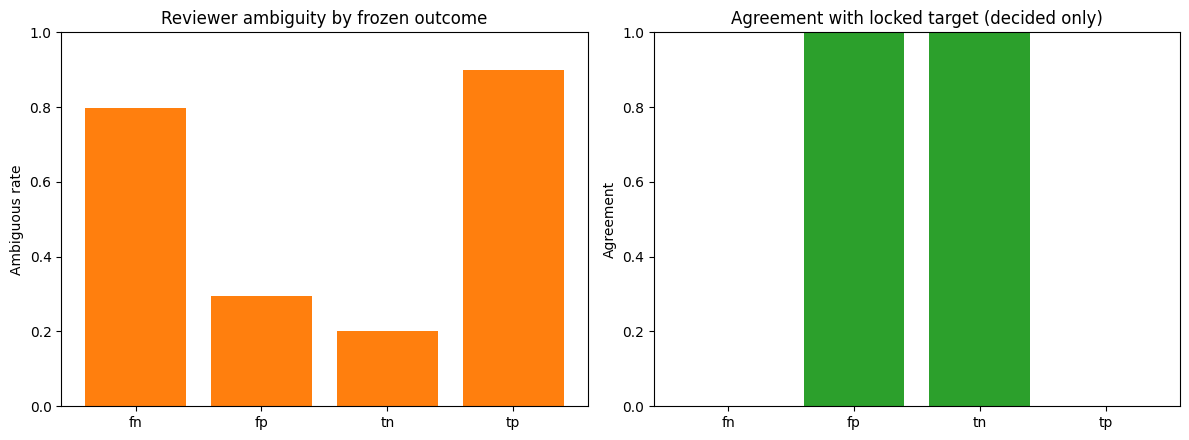

In [57]:
if MODE == "analyze_review" and ANALYSIS is not None:
    plot = pd.DataFrame(ANALYSIS["by_operating_outcome"])
    figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(plot["operating_outcome"], plot["ambiguous_rate"], color="tab:orange")
    axes[0].set_title("Reviewer ambiguity by frozen outcome")
    axes[0].set_ylabel("Ambiguous rate")
    axes[0].set_ylim(0, 1)
    agreement = plot["locked_label_agreement"].fillna(0)
    axes[1].bar(plot["operating_outcome"], agreement, color="tab:green")
    axes[1].set_title("Agreement with locked target (decided only)")
    axes[1].set_ylabel("Agreement")
    axes[1].set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Review visualization becomes available after analyze_review completes.")

## 13. Terminal guard: Phase 4E-A never opens final or auto-starts training

In [58]:
def open_final_split(*args, **kwargs):
    raise PermissionError(
        "Final evaluation is intentionally unavailable in Phase 4E-A. "
        "This notebook is a non-final blinded audit, not a promotion run."
    )

if CFG["final_opened"] is not False or INPUT_LOCK["final_opened"] is not False:
    raise AssertionError("Invalid final status in Phase 4E audit contract.")

if MODE == "prepare_audit":
    print(
        "PHASE 4E-A PACK PREPARED. Complete the blinded review, save "
        "AUDIT_REVIEW_COMPLETED.csv, switch MODE to analyze_review, and rerun. "
        "Final remains closed."
    )
else:
    if ANALYSIS is None:
        raise AssertionError("Analyze mode did not produce an analysis.")
    print(
        "PHASE 4E-A REVIEW ANALYZED. No training is automatically authorized. "
        "Resolve ambiguity/disagreements and record a human go/no-go decision for a "
        "separate Phase 4E-B contract. Final remains closed."
    )

PHASE 4E-A REVIEW ANALYZED. No training is automatically authorized. Resolve ambiguity/disagreements and record a human go/no-go decision for a separate Phase 4E-B contract. Final remains closed.
